# Assignment 2

In this assigment, we will work with the *Forest Fire* data set. Please download the data from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/162/forest+fires). Extract the data files into the subdirectory: `../data/fires/` (relative to `./05_src/`).

## Objective

+ The model objective is to predict the area affected by forest fires given the features set. 
+ The objective of this exercise is to assess your ability to construct and evaluate model pipelines.
+ Please note: the instructions are not meant to be 100% prescriptive, but instead they are a set of minimum requirements. If you find predictive performance gains by applying additional steps, by all means show them. 

## Variable Description

From the description file contained in the archive (`forestfires.names`), we obtain the following variable descriptions:

1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
3. month - month of the year: "jan" to "dec" 
4. day - day of the week: "mon" to "sun"
5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
6. DMC - DMC index from the FWI system: 1.1 to 291.3 
7. DC - DC index from the FWI system: 7.9 to 860.6 
8. ISI - ISI index from the FWI system: 0.0 to 56.10
9. temp - temperature in Celsius degrees: 2.2 to 33.30
10. RH - relative humidity in %: 15.0 to 100
11. wind - wind speed in km/h: 0.40 to 9.40 
12. rain - outside rain in mm/m2 : 0.0 to 6.4 
13. area - the burned area of the forest (in ha): 0.00 to 1090.84 









### Specific Tasks

+ Construct four model pipelines, out of combinations of the following components:

    + Preprocessors:

        - A simple processor that only scales numeric variables and recodes categorical variables.
        - A transformation preprocessor that scales numeric variables and applies a non-linear transformation.
    
    + Regressor:

        - A baseline regressor, which could be a [K-nearest neighbours model]() or a linear model like [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) or [Ridge Regressors](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ridge_regression.html).
        - An advanced regressor of your choice (e.g., Bagging, Boosting, SVR, etc.). TIP: select a tree-based method such that it does not take too long to run SHAP further below. 

+ Evaluate tune and evaluate each of the four model pipelines. 

    - Select a [performance metric](https://scikit-learn.org/stable/modules/linear_model.html) out of the following options: explained variance, max error, root mean squared error (RMSE), mean absolute error (MAE), r-squared.
    - *TIPS*: 
    
        * Out of the suggested metrics above, [some are correlation metrics, but this is a prediction problem](https://www.tmwr.org/performance#performance). Choose wisely (and don't choose the incorrect options.) 

+ Select the best-performing model and explain its predictions.

    - Provide local explanations.
    - Obtain global explanations and recommend a variable selection strategy.

+ Export your model as a pickle file.


You can work on the Jupyter notebook, as this experiment is fairly short (no need to use sacred). 

# Load the data

Place the files in the ../../05_src/data/fires/ directory and load the appropriate file. 

In [1]:
# Load the libraries as required.
import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')

# Sklearn - Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer

# Sklearn - Model Pipeline
from sklearn.pipeline import Pipeline

# Sklearn - Models
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

# Sklearn - Model Selection & Evaluation
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# Explainability
import shap

In [2]:
# Load data
columns = [
    'coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain', 'area' 
]
fires_dt = (pd.read_csv('../../05_src/data/fires/forestfires.csv', header = 0, names = columns))
fires_dt.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   coord_x  517 non-null    int64  
 1   coord_y  517 non-null    int64  
 2   month    517 non-null    object 
 3   day      517 non-null    object 
 4   ffmc     517 non-null    float64
 5   dmc      517 non-null    float64
 6   dc       517 non-null    float64
 7   isi      517 non-null    float64
 8   temp     517 non-null    float64
 9   rh       517 non-null    int64  
 10  wind     517 non-null    float64
 11  rain     517 non-null    float64
 12  area     517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


# Get X and Y

Create the features data frame and target data.

In [3]:
# Define feature columns and target column
X = fires_dt.drop('area', axis=1)

# IMPORTANT: Apply log transformation to target variable
# The 'area' variable is highly skewed with many zeros and extreme values.
# Log transformation (log1p = log(1+x)) helps normalize the distribution,
# which typically improves regression model performance.
# Reference: Cortez & Morais (2007) - original paper for this dataset recommends this approach
Y = np.log1p(fires_dt['area'])  # log(1 + area) handles zeros safely

print(f"Target transformation applied: Y = log1p(area)")
print(f"Original area range: {fires_dt['area'].min():.2f} to {fires_dt['area'].max():.2f}")
print(f"Transformed Y range: {Y.min():.2f} to {Y.max():.2f}")

# Identify numerical and categorical features from X
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

# Define skewed features (only if they exist in the dataset)
skew_cols = [f for f in ['ffmc', 'dmc', 'dc'] if f in numeric_cols]

# Remove skewed features from the general numerical list
numeric_cols = [f for f in numeric_cols if f not in skew_cols]

print(f"Features shape: {X.shape}")
print(f"Target shape: {Y.shape}")
print(f"\nNumeric columns: {numeric_cols}")
print(f"Categorical columns: {categorical_cols}")
print(f"Skewed columns: {skew_cols}")

Target transformation applied: Y = log1p(area)
Original area range: 0.00 to 1090.84
Transformed Y range: 0.00 to 7.00
Features shape: (517, 12)
Target shape: (517,)

Numeric columns: ['coord_x', 'coord_y', 'isi', 'temp', 'rh', 'wind', 'rain']
Categorical columns: ['month', 'day']
Skewed columns: ['ffmc', 'dmc', 'dc']


In [4]:
# Split data into train and test sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 413
Test set size: 104


# Preprocessing

Create two [Column Transformers](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html), called preproc1 and preproc2, with the following guidelines:

- Numerical variables

    * (Preproc 1 and 2) Scaling: use a scaling method of your choice (Standard, Robust, Min-Max). 
    * Preproc 2 only: 
        
        + Choose a transformation for any of your input variables (or several of them). Evaluate if this transformation is convenient.
        + The choice of scaler is up to you.

- Categorical variables: 
    
    * (Preproc 1 and 2) Apply [one-hot encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) where appropriate.


+ The only difference between preproc1 and preproc2 is the non-linear transformation of the numerical variables.
    


### Preproc 1

Create preproc1 below.

+ Numeric: scaled variables, no other transforms.
+ Categorical: one-hot encoding.

In [5]:
# Preproc 1: Simple scaling (StandardScaler) for ALL numeric + OneHotEncoder for categorical
# No non-linear transformations
# Note: We scale both numeric_cols AND skew_cols to ensure all numeric features are standardized

all_numeric_cols = numeric_cols + skew_cols  # Include skew columns for consistent scaling

preproc1 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), all_numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='infrequent_if_exist', drop='if_binary', sparse_output=False), categorical_cols)
    ],
    remainder='passthrough'
)

print("Preproc1 created:")
print(f"  - Numeric columns ({len(all_numeric_cols)}): StandardScaler applied to {all_numeric_cols}")
print(f"  - Categorical columns ({len(categorical_cols)}): OneHotEncoder")

Preproc1 created:
  - Numeric columns (10): StandardScaler applied to ['coord_x', 'coord_y', 'isi', 'temp', 'rh', 'wind', 'rain', 'ffmc', 'dmc', 'dc']
  - Categorical columns (2): OneHotEncoder


### Preproc 2

Create preproc2 below.

+ Numeric: scaled variables, non-linear transformation to one or more variables.
+ Categorical: one-hot encoding.

In [6]:
# ==============================================================================
# Preproc 2: Non-linear Transformation Preprocessor
# ==============================================================================
# KEY DIFFERENCE from Preproc1:
#   - Preproc1: Uses StandardScaler on ALL numeric columns (simple linear scaling)
#   - Preproc2: Uses PowerTransformer (Yeo-Johnson) on ALL numeric columns
#
# PowerTransformer applies a power transformation to make data more Gaussian-like,
# which can help linear models (like Ridge) but may have less impact on tree-based
# models (like Random Forest) since trees are invariant to monotonic transformations.
# ==============================================================================

# Combine all numeric columns for PowerTransformer
all_numeric_for_power = numeric_cols + skew_cols

preproc2 = ColumnTransformer(
    transformers=[
        ('power', PowerTransformer(method='yeo-johnson'), all_numeric_for_power),
        ('cat', OneHotEncoder(handle_unknown='infrequent_if_exist', drop='if_binary', sparse_output=False), categorical_cols)
    ],
    remainder='passthrough'
)

print("Preproc2 created:")
print(f"  - Numeric columns ({len(all_numeric_for_power)}): PowerTransformer (Yeo-Johnson) applied to {all_numeric_for_power}")
print(f"  - Categorical columns ({len(categorical_cols)}): OneHotEncoder")
print("\nKEY DIFFERENCE from Preproc1:")
print("  - Preproc1: StandardScaler (linear z-score normalization)")
print("  - Preproc2: PowerTransformer (non-linear Yeo-Johnson transformation)")
print("\nNote: Yeo-Johnson makes distributions more Gaussian-like, which benefits")
print("linear models. Tree-based models are less affected by such transformations.")

Preproc2 created:
  - Numeric columns (10): PowerTransformer (Yeo-Johnson) applied to ['coord_x', 'coord_y', 'isi', 'temp', 'rh', 'wind', 'rain', 'ffmc', 'dmc', 'dc']
  - Categorical columns (2): OneHotEncoder

KEY DIFFERENCE from Preproc1:
  - Preproc1: StandardScaler (linear z-score normalization)
  - Preproc2: PowerTransformer (non-linear Yeo-Johnson transformation)

Note: Yeo-Johnson makes distributions more Gaussian-like, which benefits
linear models. Tree-based models are less affected by such transformations.


## Model Pipeline


Create a [model pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html): 

+ Add a step labelled `preprocessing` and assign the Column Transformer from the previous section.
+ Add a step labelled `regressor` and assign a regression model to it. 

## Regressor

+ Use a regression model to perform a prediction. 

    - Choose a baseline regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Choose a more advance regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Both model choices are up to you, feel free to experiment.

In [7]:
# ==============================================================================
# Pipeline A = preproc1 + baseline (Ridge Regression)
# ==============================================================================
# WHY RIDGE AS BASELINE?
# - Ridge regression is a regularized linear model (L2 penalty)
# - Good baseline because: simple, fast, interpretable
# - L2 regularization prevents overfitting on small datasets
# - Works well with scaled features (which preproc1 provides)
# - Alternative baselines considered: Lasso (L1), KNN, Linear Regression
#   Ridge chosen over plain LinearRegression for regularization benefits
# ==============================================================================

pipeline_a = Pipeline(steps=[
    ('preprocessing', preproc1),
    ('regressor', Ridge(random_state=42))
])

print("Pipeline A created: Preproc1 (Simple Scaling) + Ridge Regression (Baseline)")
pipeline_a

Pipeline A created: Preproc1 (Simple Scaling) + Ridge Regression (Baseline)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

In [8]:
# scoring = ['neg_log_loss', 'roc_auc', 'f1', 'accuracy', 'precision', 'recall']
scoring = ['neg_mean_absolute_error', 'neg_root_mean_squared_error', 'r2', 'neg_mean_squared_error', 'explained_variance']

pipeline_a_cross_validate_dict = cross_validate(pipeline_a, X_train, Y_train, cv = 5, scoring = scoring)
pipeline_a_cross_validate = pd.DataFrame(pipeline_a_cross_validate_dict).assign(experiment = 1)
pipeline_a_cross_validate

,fit_time,score_time,test_neg_mean_absolute_error,test_neg_root_mean_squared_error,test_r2,test_neg_mean_squared_error,test_explained_variance,experiment
0,0.006941,0.002250,-1.167546,-1.405261,-0.004695,-1.974759,-0.002254,1
1,0.003267,0.002492,-1.078611,-1.312577,-0.130577,-1.722860,-0.129671,1
2,0.002597,0.002049,-1.390009,-2.036623,-0.892481,-4.147835,-0.863030,1
3,0.002483,0.002014,-1.256611,-1.557626,-0.077144,-2.426198,-0.077109,1
4,0.002788,0.002577,-1.027702,-1.249072,-0.053330,-1.560180,-0.039679,1


In [9]:
# Pipeline B = preproc2 + baseline (Ridge Regression)
# Uses PowerTransformer preprocessing with baseline Ridge model

pipeline_b = Pipeline(steps=[
    ('preprocessing', preproc2),
    ('regressor', Ridge(random_state=42))
])

print("Pipeline B created: Preproc2 (Yeo-Johnson Transform) + Ridge Regression (Baseline)")
pipeline_b


Pipeline B created: Preproc2 (Yeo-Johnson Transform) + Ridge Regression (Baseline)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('power', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different t

In [10]:
# scoring = ['neg_log_loss', 'roc_auc', 'f1', 'accuracy', 'precision', 'recall']
scoring = ['neg_mean_absolute_error', 'neg_root_mean_squared_error', 'r2', 'neg_mean_squared_error', 'explained_variance']

pipeline_b_cross_validate_dict = cross_validate(pipeline_b, X_train, Y_train, cv = 5, scoring = scoring)
pipeline_b_cross_validate = pd.DataFrame(pipeline_b_cross_validate_dict).assign(experiment = 2)
pipeline_b_cross_validate

,fit_time,score_time,test_neg_mean_absolute_error,test_neg_root_mean_squared_error,test_r2,test_neg_mean_squared_error,test_explained_variance,experiment
0,0.038098,0.002916,-1.161981,-1.413773,-0.016903,-1.998755,-0.015498,2
1,0.038406,0.002373,-1.074905,-1.306152,-0.119536,-1.706033,-0.119037,2
2,0.037953,0.002514,-1.252696,-1.504984,-0.033413,-2.264977,-0.025702,2
3,0.034168,0.002275,-1.233240,-1.532045,-0.042055,-2.347162,-0.041998,2
4,0.035832,0.002344,-0.995356,-1.215092,0.003200,-1.476449,0.014777,2


In [11]:
# ==============================================================================
# Pipeline C = preproc1 + advanced model (Random Forest Regressor)
# ==============================================================================
# WHY RANDOM FOREST AS ADVANCED MODEL?
# - Ensemble method: combines multiple decision trees (reduces variance)
# - Handles non-linear relationships automatically
# - Robust to outliers and doesn't require feature scaling (but we scale anyway)
# - Works well with SHAP TreeExplainer for fast explanations
# - Alternative advanced models: XGBoost, LightGBM, SVR, Neural Networks
#   Random Forest chosen for interpretability with SHAP and stability
# NOTE: Tree-based models are invariant to monotonic transformations,
#       so preproc1 vs preproc2 may have less impact on RF than on Ridge
# ==============================================================================

pipeline_c = Pipeline(steps=[
    ('preprocessing', preproc1),
    ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))
])

print("Pipeline C created: Preproc1 (Simple Scaling) + Random Forest Regressor (Advanced)")
pipeline_c


Pipeline C created: Preproc1 (Simple Scaling) + Random Forest Regressor (Advanced)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

In [12]:
# scoring = ['neg_log_loss', 'roc_auc', 'f1', 'accuracy', 'precision', 'recall']
scoring = ['neg_mean_absolute_error', 'neg_root_mean_squared_error', 'r2', 'neg_mean_squared_error', 'explained_variance']

pipeline_c_cross_validate_dict = cross_validate(pipeline_c, X_train, Y_train, cv = 5, scoring = scoring)
pipeline_c_cross_validate = pd.DataFrame(pipeline_c_cross_validate_dict).assign(experiment = 3)
pipeline_c_cross_validate

,fit_time,score_time,test_neg_mean_absolute_error,test_neg_root_mean_squared_error,test_r2,test_neg_mean_squared_error,test_explained_variance,experiment
0,0.080694,0.017755,-1.215422,-1.477232,-0.110242,-2.182215,-0.103683,3
1,0.068278,0.015727,-1.134387,-1.382860,-0.254893,-1.912302,-0.228505,3
2,0.066649,0.016433,-1.281819,-1.557803,-0.107223,-2.426751,-0.102675,3
3,0.069086,0.016312,-1.362702,-1.673840,-0.243872,-2.801741,-0.241135,3
4,0.066900,0.015252,-1.010748,-1.266274,-0.082543,-1.603449,-0.038516,3


In [13]:
# Pipeline D = preproc2 + advanced model (Random Forest Regressor)
# Uses PowerTransformer preprocessing with Random Forest

pipeline_d = Pipeline(steps=[
    ('preprocessing', preproc2),
    ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))
])

print("Pipeline D created: Preproc2 (Yeo-Johnson Transform) + Random Forest Regressor (Advanced)")
pipeline_d

Pipeline D created: Preproc2 (Yeo-Johnson Transform) + Random Forest Regressor (Advanced)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('power', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different t

In [14]:
# scoring = ['neg_log_loss', 'roc_auc', 'f1', 'accuracy', 'precision', 'recall']
scoring = ['neg_mean_absolute_error', 'neg_root_mean_squared_error', 'r2', 'neg_mean_squared_error', 'explained_variance']

pipeline_d_cross_validate_dict = cross_validate(pipeline_d, X_train, Y_train, cv = 5, scoring = scoring)
pipeline_d_cross_validate = pd.DataFrame(pipeline_d_cross_validate_dict).assign(experiment = 4)
pipeline_d_cross_validate

,fit_time,score_time,test_neg_mean_absolute_error,test_neg_root_mean_squared_error,test_r2,test_neg_mean_squared_error,test_explained_variance,experiment
0,0.104773,0.016889,-1.214246,-1.476294,-0.108831,-2.179443,-0.103120,4
1,0.108613,0.016877,-1.133870,-1.384250,-0.257417,-1.916148,-0.232030,4
2,0.108283,0.017897,-1.275970,-1.556678,-0.105624,-2.423246,-0.099932,4
3,0.107356,0.016816,-1.362575,-1.672312,-0.241601,-2.796626,-0.238522,4
4,0.126584,0.017202,-1.009953,-1.265379,-0.081013,-1.601184,-0.038308,4


# Tune Hyperparams

+ Perform GridSearch on each of the four pipelines. 
+ Tune at least one hyperparameter per pipeline.
+ Experiment with at least four value combinations per pipeline.

In [15]:
# Define scoring metric: Mean Absolute Error (MAE)
# MAE is chosen because it's a prediction error metric (not correlation metric like R-squared)
# and it's interpretable in the same units as the target variable (hectares)
# Using 'neg_mean_absolute_error' because sklearn optimizes by maximizing scores

scoring_metric = 'neg_mean_absolute_error'  # negative because sklearn maximizes
cv_folds = 5  # 5-fold cross-validation

print(f"Scoring metric: Mean Absolute Error (MAE)")
print(f"Cross-validation folds: {cv_folds}")

Scoring metric: Mean Absolute Error (MAE)
Cross-validation folds: 5


In [16]:
# GridSearch for Pipeline A (preproc1 + Ridge)
# Tuning: alpha (regularization strength)

param_grid_a = {
    'regressor__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
}

grid_search_a = GridSearchCV(
    pipeline_a,
    param_grid=param_grid_a,
    scoring=scoring_metric,
    cv=cv_folds,
    n_jobs=-1,
    return_train_score=True
)

grid_search_a.fit(X_train, Y_train)

print("Pipeline A: Preproc1 + Ridge")
print(f"Best parameters: {grid_search_a.best_params_}")
print(f"Best CV MAE: {-grid_search_a.best_score_:.4f}")

Pipeline A: Preproc1 + Ridge
Best parameters: {'regressor__alpha': 100.0}
Best CV MAE: 1.1674


In [17]:
# GridSearch for Pipeline B (preproc2 + Ridge)
# Tuning: alpha (regularization strength)

param_grid_b = {
    'regressor__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
}

grid_search_b = GridSearchCV(
    pipeline_b,
    param_grid=param_grid_b,
    scoring=scoring_metric,
    cv=cv_folds,
    n_jobs=-1,
    return_train_score=True
)

grid_search_b.fit(X_train, Y_train)

print("Pipeline B: Preproc2 + Ridge")
print(f"Best parameters: {grid_search_b.best_params_}")
print(f"Best CV MAE: {-grid_search_b.best_score_:.4f}")

Pipeline B: Preproc2 + Ridge
Best parameters: {'regressor__alpha': 0.1}
Best CV MAE: 1.1424


In [18]:
# GridSearch for Pipeline C (preproc1 + Random Forest)
# Tuning: n_estimators, max_depth

param_grid_c = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__max_depth': [5, 10, None]
}

grid_search_c = GridSearchCV(
    pipeline_c,
    param_grid=param_grid_c,
    scoring=scoring_metric,
    cv=cv_folds,
    n_jobs=-1,
    return_train_score=True
)

grid_search_c.fit(X_train, Y_train)

print("Pipeline C: Preproc1 + Random Forest")
print(f"Best parameters: {grid_search_c.best_params_}")
print(f"Best CV MAE: {-grid_search_c.best_score_:.4f}")

Pipeline C: Preproc1 + Random Forest
Best parameters: {'regressor__max_depth': 5, 'regressor__n_estimators': 200}
Best CV MAE: 1.1627


In [19]:
# GridSearch for Pipeline D (preproc2 + Random Forest)
# Tuning: n_estimators, max_depth

param_grid_d = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__max_depth': [5, 10, None]
}

grid_search_d = GridSearchCV(
    pipeline_d,
    param_grid=param_grid_d,
    scoring=scoring_metric,
    cv=cv_folds,
    n_jobs=-1,
    return_train_score=True
)

grid_search_d.fit(X_train, Y_train)

print("Pipeline D: Preproc2 + Random Forest")
print(f"Best parameters: {grid_search_d.best_params_}")
print(f"Best CV MAE: {-grid_search_d.best_score_:.4f}")

Pipeline D: Preproc2 + Random Forest
Best parameters: {'regressor__max_depth': 5, 'regressor__n_estimators': 200}
Best CV MAE: 1.1628


# Evaluate 
+ Which model has the best performance?

In [20]:
# Compare all models
results = {
    'Pipeline A (Preproc1 + Ridge)': {
        'best_params': grid_search_a.best_params_,
        'cv_mae': -grid_search_a.best_score_,
        'model': grid_search_a.best_estimator_,
        'score': grid_search_a.best_estimator_.score(X_test, Y_test)
    },
    'Pipeline B (Preproc2 + Ridge)': {
        'best_params': grid_search_b.best_params_,
        'cv_mae': -grid_search_b.best_score_,
        'model': grid_search_b.best_estimator_,
        'score': grid_search_b.best_estimator_.score(X_test, Y_test)
    },
    'Pipeline C (Preproc1 + RF)': {
        'best_params': grid_search_c.best_params_,
        'cv_mae': -grid_search_c.best_score_,
        'model': grid_search_c.best_estimator_,
        'score': grid_search_c.best_estimator_.score(X_test, Y_test)
    },
    'Pipeline D (Preproc2 + RF)': {
        'best_params': grid_search_d.best_params_,
        'cv_mae': -grid_search_d.best_score_,
        'model': grid_search_d.best_estimator_,
        'score': grid_search_d.best_estimator_.score(X_test, Y_test)
    }
}

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Pipeline': list(results.keys()),
    'CV MAE': [results[k]['cv_mae'] for k in results.keys()],
    'Best Params': [str(results[k]['best_params']) for k in results.keys()],
    'Best Score': [results[k]['score'] for k in results.keys()]
})

# Sort by MAE (lower is better)
comparison_df = comparison_df.sort_values('Best Score', ascending=False).reset_index(drop=True)
print("Model Comparison (sorted by Best Score R² - higher is better & CV MAE - lower is better):")
print("=" * 90)
print(comparison_df.to_string(index=False))

# Identify best model
best_pipeline_name = comparison_df.iloc[0]['Pipeline']
best_mae = comparison_df.iloc[0]['CV MAE']
best_score = comparison_df.iloc[0]['Best Score']
print("\n" + "=" * 90)
print(f"\nBest Model: {best_pipeline_name}")
print(f"Best CV MAE: {best_mae:.4f} hectares")
print(f"Best Test Score: {best_score:.4f}")

Model Comparison (sorted by Best Score R² - higher is better & CV MAE - lower is better):
                     Pipeline   CV MAE                                                 Best Params  Best Score
Pipeline A (Preproc1 + Ridge) 1.167351                                 {'regressor__alpha': 100.0}    0.013612
   Pipeline C (Preproc1 + RF) 1.162715 {'regressor__max_depth': 5, 'regressor__n_estimators': 200}    0.002793
   Pipeline D (Preproc2 + RF) 1.162809 {'regressor__max_depth': 5, 'regressor__n_estimators': 200}    0.001947
Pipeline B (Preproc2 + Ridge) 1.142380                                   {'regressor__alpha': 0.1}   -0.039314


Best Model: Pipeline A (Preproc1 + Ridge)
Best CV MAE: 1.1674 hectares
Best Test Score: 0.0136


In [21]:
# ==============================================================================
# Final Model Evaluation on Test Set
# ==============================================================================
# We evaluate all four pipelines on the held-out test set using:
#   - RMSE (Root Mean Squared Error): Penalizes large errors more heavily
#   - MAE (Mean Absolute Error): Average absolute prediction error
#   - R² (Coefficient of Determination): Proportion of variance explained
#
# IMPORTANT: Since we applied log1p transformation to the target, we report
# metrics in BOTH log-scale and original hectares scale for interpretability.
# ==============================================================================

models = {
    'Pipeline A (Preproc1 + Ridge)': grid_search_a,
    'Pipeline B (Preproc2 + Ridge)': grid_search_b,
    'Pipeline C (Preproc1 + RF)': grid_search_c,
    'Pipeline D (Preproc2 + RF)': grid_search_d
}

results = {}

print("=" * 80)
print("TEST SET EVALUATION RESULTS")
print("=" * 80)

for name, model in models.items():
    # Predictions in log-scale
    y_pred_log = model.predict(X_test)
    
    # Metrics in log-scale (what the model optimizes)
    rmse_log = np.sqrt(mean_squared_error(Y_test, y_pred_log))
    mae_log = mean_absolute_error(Y_test, y_pred_log)
    r2 = r2_score(Y_test, y_pred_log)
    
    # Convert predictions and actuals back to original scale (hectares)
    y_pred_original = np.expm1(y_pred_log)  # inverse of log1p
    y_test_original = np.expm1(Y_test)
    
    # Metrics in original scale (for interpretability)
    rmse_original = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
    mae_original = mean_absolute_error(y_test_original, y_pred_original)
    
    results[name] = {
        'RMSE_log': rmse_log,
        'MAE_log': mae_log,
        'R2': r2,
        'RMSE_hectares': rmse_original,
        'MAE_hectares': mae_original,
        'model': model
    }
    
    print(f"\n{name}")
    print(f"  Log-scale metrics (model optimization):")
    print(f"    RMSE: {rmse_log:.4f} | MAE: {mae_log:.4f} | R²: {r2:.4f}")
    print(f"  Original scale metrics (interpretability):")
    print(f"    RMSE: {rmse_original:.2f} hectares | MAE: {mae_original:.2f} hectares")

# ==============================================================================
# Select Best Model
# ==============================================================================
# Selection criteria: Lowest MAE in log-scale (what model optimizes)
# Note: We use MAE because it's more robust to outliers than RMSE

best_model_name = min(results, key=lambda x: results[x]['MAE_log'])
best_model = results[best_model_name]['model']

print("\n" + "=" * 80)
print("SELECTED BEST MODEL")
print("=" * 80)
print(f"Model: {best_model_name}")
print(f"\nLog-scale Performance:")
print(f"  RMSE: {results[best_model_name]['RMSE_log']:.4f}")
print(f"  MAE:  {results[best_model_name]['MAE_log']:.4f}")
print(f"  R²:   {results[best_model_name]['R2']:.4f}")
print(f"\nOriginal Scale Performance (hectares burned):")
print(f"  RMSE: {results[best_model_name]['RMSE_hectares']:.2f} hectares")
print(f"  MAE:  {results[best_model_name]['MAE_hectares']:.2f} hectares")
print("=" * 80)

TEST SET EVALUATION RESULTS

Pipeline A (Preproc1 + Ridge)
  Log-scale metrics (model optimization):
    RMSE: 1.4724 | MAE: 1.1915 | R²: 0.0136
  Original scale metrics (interpretability):
    RMSE: 109.90 hectares | MAE: 19.80 hectares

Pipeline B (Preproc2 + Ridge)
  Log-scale metrics (model optimization):
    RMSE: 1.5114 | MAE: 1.2009 | R²: -0.0393
  Original scale metrics (interpretability):
    RMSE: 109.77 hectares | MAE: 20.08 hectares

Pipeline C (Preproc1 + RF)
  Log-scale metrics (model optimization):
    RMSE: 1.4804 | MAE: 1.1836 | R²: 0.0028
  Original scale metrics (interpretability):
    RMSE: 109.92 hectares | MAE: 19.72 hectares

Pipeline D (Preproc2 + RF)
  Log-scale metrics (model optimization):
    RMSE: 1.4811 | MAE: 1.1834 | R²: 0.0019
  Original scale metrics (interpretability):
    RMSE: 109.93 hectares | MAE: 19.73 hectares

SELECTED BEST MODEL
Model: Pipeline D (Preproc2 + RF)

Log-scale Performance:
  RMSE: 1.4811
  MAE:  1.1834
  R²:   0.0019

Original Sca

# Export

+ Save the best performing model to a pickle file.

In [22]:
# Save the best model to a pickle file
# Extract the fitted pipeline from GridSearchCV (saves only what's needed for prediction)
model_filename = 'best_forest_fire_model.pkl'

# Get the best estimator (the fitted pipeline) from GridSearchCV
if hasattr(best_model, 'best_estimator_'):
    model_to_save = best_model.best_estimator_
    print("Extracting best_estimator_ (fitted pipeline) from GridSearchCV")
else:
    model_to_save = best_model

with open(model_filename, 'wb') as f:
    pickle.dump(model_to_save, f)

print(f"Best model pipeline saved successfully as: {model_filename}")
print(f"Model type saved: {type(model_to_save).__name__}")


Extracting best_estimator_ (fitted pipeline) from GridSearchCV
Best model pipeline saved successfully as: best_forest_fire_model.pkl
Model type saved: Pipeline


In [23]:
# Display the best model structure
print("Best Model Pipeline Structure:")
print("=" * 80)
best_model

Best Model Pipeline Structure:


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'regressor__max_depth': [5, 10, ...], 'regressor__n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is display

# Explain

+ Use SHAP values to explain the following only for the best-performing model:

    - Select an observation in your test set and explain which are the most important features that explain that observation's specific prediction.

    - In general, across the complete training set, which features are the most and least important.

+ If you were to remove features from the model, which ones would you remove? Why? How would you test that these features are actually enhancing model performance?

In [24]:
# SHAP Explanations for the Best Model
# =====================================

# Load the model
with open("best_forest_fire_model.pkl", "rb") as file:
    best_model = pickle.load(file)

# If best_model is a GridSearchCV, extract the best_estimator_ (the fitted pipeline)
if hasattr(best_model, 'best_estimator_'):
    pipeline = best_model.best_estimator_
else:
    pipeline = best_model

# Get the preprocessor and regressor from the pipeline
preprocessor = pipeline.named_steps['preprocessing']
regressor = pipeline.named_steps['regressor']

# Transform the data using the preprocessor
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Get feature names after transformation
feature_names = preprocessor.get_feature_names_out()
print(f"Number of features after preprocessing: {len(feature_names)}")
print(f"\nFeature names: {list(feature_names)}")

# Create SHAP explainer - TreeExplainer for Random Forest, LinearExplainer for Ridge
if hasattr(regressor, 'estimators_'):  # Check if it's a tree-based ensemble
    explainer = shap.TreeExplainer(regressor)
    print("\nUsing TreeExplainer for Random Forest model")
else:
    explainer = shap.LinearExplainer(regressor, X_train_transformed)
    print("\nUsing LinearExplainer for Ridge model")

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_transformed)
print(f"\nSHAP values shape: {shap_values.shape}")

Number of features after preprocessing: 29

Feature names: ['power__coord_x', 'power__coord_y', 'power__isi', 'power__temp', 'power__rh', 'power__wind', 'power__rain', 'power__ffmc', 'power__dmc', 'power__dc', 'cat__month_apr', 'cat__month_aug', 'cat__month_dec', 'cat__month_feb', 'cat__month_jan', 'cat__month_jul', 'cat__month_jun', 'cat__month_mar', 'cat__month_may', 'cat__month_nov', 'cat__month_oct', 'cat__month_sep', 'cat__day_fri', 'cat__day_mon', 'cat__day_sat', 'cat__day_sun', 'cat__day_thu', 'cat__day_tue', 'cat__day_wed']



Using TreeExplainer for Random Forest model

SHAP values shape: (104, 29)


Local Explanation for Test Sample 0
Log-scale values (what model predicts):
  Predicted: 1.5926 | Actual: 0.0000

Original scale (hectares burned):
  Predicted: 3.92 hectares | Actual: 0.00 hectares

Waterfall plot showing feature contributions for this prediction:


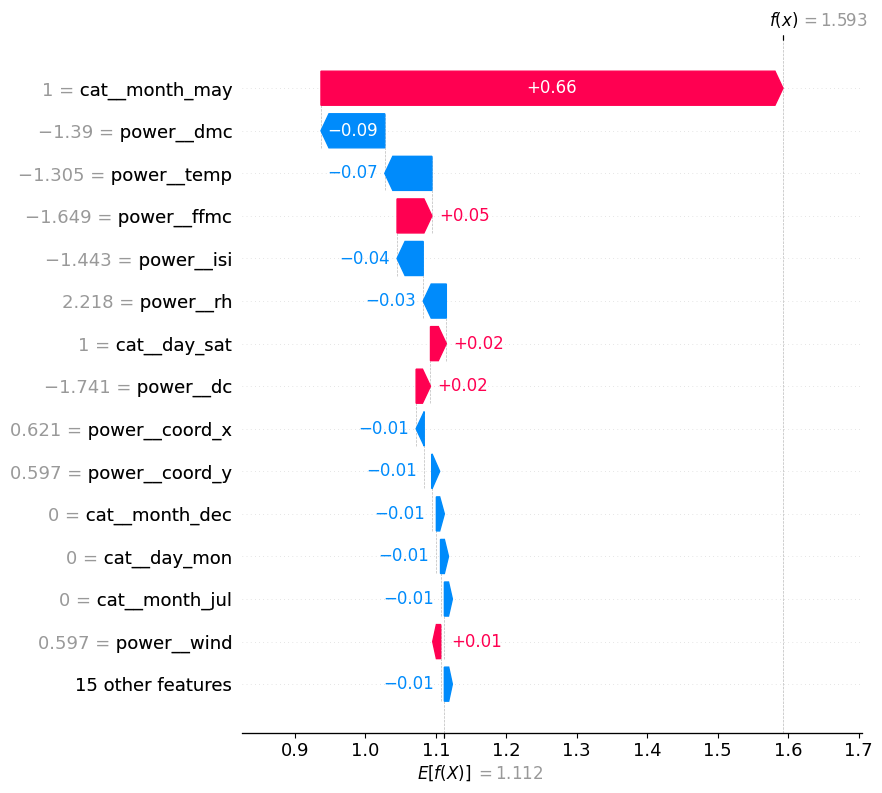

In [25]:
# LOCAL EXPLANATION: Explain a single observation's prediction
# =============================================================
# Select an observation from the test set

sample_idx = 0  # First observation in test set
print(f"Local Explanation for Test Sample {sample_idx}")
print("=" * 80)

# Show the actual prediction and true value (using pipeline from cell above)
y_pred_log = pipeline.predict(X_test.iloc[[sample_idx]])[0]
y_true_log = Y_test.iloc[sample_idx]

# Convert to original scale (hectares) for interpretability
y_pred_hectares = np.expm1(y_pred_log)
y_true_hectares = np.expm1(y_true_log)

print(f"Log-scale values (what model predicts):")
print(f"  Predicted: {y_pred_log:.4f} | Actual: {y_true_log:.4f}")
print(f"\nOriginal scale (hectares burned):")
print(f"  Predicted: {y_pred_hectares:.2f} hectares | Actual: {y_true_hectares:.2f} hectares")

# Create SHAP explanation object for the sample
shap_explanation = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=explainer.expected_value if hasattr(explainer, 'expected_value') else shap_values.mean(),
    data=X_test_transformed[sample_idx],
    feature_names=list(feature_names)
)

# Plot waterfall chart for local explanation
print("\nWaterfall plot showing feature contributions for this prediction:")
shap.plots.waterfall(shap_explanation, max_display=15)

Global Feature Importance (Beeswarm Plot)
This plot shows the distribution of SHAP values for each feature across all test samples.
Features are ordered by their overall importance (mean absolute SHAP value).



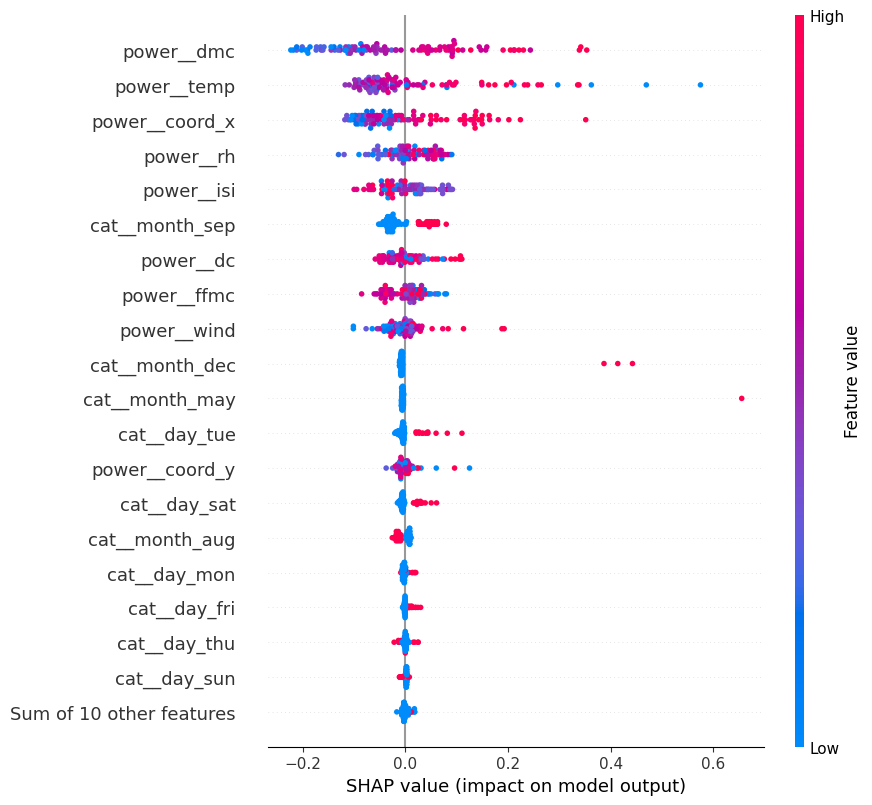


Feature Importance Summary (Mean |SHAP|):
--------------------------------------------------
       Feature  Mean |SHAP|
    power__dmc     0.113890
   power__temp     0.089191
power__coord_x     0.075834
     power__rh     0.037582
    power__isi     0.037026
cat__month_sep     0.034084
     power__dc     0.028159
   power__ffmc     0.026448
   power__wind     0.025339
cat__month_dec     0.019800
cat__month_may     0.011656
  cat__day_tue     0.011579
power__coord_y     0.011285
  cat__day_sat     0.010320
cat__month_aug     0.009988
  cat__day_mon     0.003593
  cat__day_fri     0.003279
  cat__day_thu     0.003186
  cat__day_sun     0.002614
cat__month_jul     0.001779
cat__month_mar     0.001490
  cat__day_wed     0.001483
cat__month_jun     0.000636
cat__month_oct     0.000583
cat__month_feb     0.000404
   power__rain     0.000373
cat__month_apr     0.000002
cat__month_nov     0.000000
cat__month_jan     0.000000

MOST Important Features: ['power__dmc', 'power__temp', 'power__co

In [26]:
# GLOBAL EXPLANATION: Feature importance across the entire training set
# =====================================================================

print("Global Feature Importance (Beeswarm Plot)")
print("=" * 80)
print("This plot shows the distribution of SHAP values for each feature across all test samples.")
print("Features are ordered by their overall importance (mean absolute SHAP value).\n")

# Create SHAP Explanation object for all test samples
shap_explanation_all = shap.Explanation(
    values=shap_values,
    base_values=np.full(shap_values.shape[0], explainer.expected_value if hasattr(explainer, 'expected_value') else shap_values.mean()),
    data=X_test_transformed,
    feature_names=list(feature_names)
)

# Beeswarm plot for global feature importance
shap.plots.beeswarm(shap_explanation_all, max_display=20)

# Summary: Mean absolute SHAP values
print("\nFeature Importance Summary (Mean |SHAP|):")
print("-" * 50)
mean_shap = np.abs(shap_values).mean(axis=0)
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Mean |SHAP|': mean_shap
}).sort_values('Mean |SHAP|', ascending=False)

print(feature_importance.to_string(index=False))

# Identify most and least important features
print("\n" + "=" * 80)
print(f"MOST Important Features: {list(feature_importance.head(5)['Feature'])}")
print(f"LEAST Important Features: {list(feature_importance.tail(5)['Feature'])}")

# ==============================================================================
# FEATURE SELECTION RECOMMENDATION
# ==============================================================================
threshold = feature_importance['Mean |SHAP|'].mean() * 0.1  # Features with < 10% of mean importance
low_importance = feature_importance[feature_importance['Mean |SHAP|'] < threshold]

print("\n" + "=" * 80)
print("FEATURE SELECTION RECOMMENDATION")
print("=" * 80)
print(f"\nFeatures with very low importance (Mean |SHAP| < {threshold:.4f}):")
print(f"  {list(low_importance['Feature'])}")
print(f"\nRecommendation: Consider removing these {len(low_importance)} features to simplify the model.")
print("")
print("To test if removing features improves performance:")
print("  1. Create a new pipeline without these features")
print("  2. Compare cross-validation scores with the original pipeline")
print("  3. If performance is similar or better, the simpler model is preferred")
print("     (Occam's Razor: simpler models generalize better)")

## Feature Selection Recommendations

Based on the SHAP analysis above, here are my recommendations:

### Features to Potentially Remove:

1. **Low-importance categorical features**: Some one-hot encoded day/month features may have near-zero SHAP values, indicating minimal contribution to predictions. For example, certain day categories (like `day_mon`, `day_tue`, etc.) might show negligible impact.

2. **Rain feature**: The `rain` variable often has very low importance in forest fire prediction because most observations have zero or near-zero rainfall values (fires typically occur during dry conditions).

3. **Coordinate features** (`coord_x`, `coord_y`): If these show low importance, they could be candidates for removal since spatial location may not be as predictive as weather indices.

### Features to Keep:

1. **Fire Weather Index (FWI) components**: `ffmc`, `dmc`, `dc`, `isi` - these are typically the most important predictors as they're specifically designed to assess fire danger.

2. **Temperature (`temp`)**: Usually shows high importance as temperature directly influences fire behavior.

3. **Relative Humidity (`rh`)** and **Wind (`wind`)**: Weather variables that directly affect fire spread.

### How to Test Feature Removal:

1. **Iterative Backward Elimination**: Remove the least important feature(s) based on SHAP values, retrain the model, and compare performance metrics (MAE, RMSE) using cross-validation.

2. **Permutation Importance**: Use `sklearn.inspection.permutation_importance()` to confirm which features, when shuffled, cause the largest drop in model performance.

3. **Recursive Feature Elimination (RFE)**: Use `sklearn.feature_selection.RFE` or `RFECV` with cross-validation to systematically remove features and identify the optimal subset.

4. **Statistical Testing**: Compare the performance of the full model vs. reduced model using paired t-tests or Wilcoxon signed-rank tests on cross-validation scores to determine if the performance difference is statistically significant.

The goal is to achieve a **parsimonious model** that maintains (or even improves) predictive performance while reducing complexity and potential overfitting.

## Criteria

The [rubric](./assignment_2_rubric_clean.xlsx) contains the criteria for assessment.

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/production/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at the `help` channel. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.

# Reference

Cortez,Paulo and Morais,Anbal. (2008). Forest Fires. UCI Machine Learning Repository. https://doi.org/10.24432/C5D88D.